In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from numpy.lib.stride_tricks import sliding_window_view

In [2]:
def sigmoid(Z):
    """
    Implements the sigmoid activation in numpy
    
    Arguments:
    Z -- numpy array of any shape
    
    Returns:
    A -- output of sigmoid(z), same shape as Z
    cache -- returns Z as well, useful during backpropagation
    """
    
    A = 1/(1+np.exp(-Z))
    cache = Z
    
    return A, cache

In [3]:
def relu(Z):
    """
    Implement the RELU function.

    Arguments:
    Z -- Output of the linear layer, of any shape

    Returns:
    A -- Post-activation parameter, of the same shape as Z
    cache -- a python dictionary containing "A" ; stored for computing the backward pass efficiently
    """

    A = np.maximum(0,Z)
    
    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache

In [4]:
def tanh(Z):
    
    A = np.tanh(Z)

    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache

In [5]:
def tanh_backward(dA, cache):
    
    Z = cache
    A = np.tanh(Z)
    dZ = dA * (1 - A**2)

    assert(dZ.shape == Z.shape)

    return dZ

In [6]:
def relu_backward(dA, cache):
    """
    Implement the backward propagation for a single RELU unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
 
    Z = cache
    dZ = np.array(dA, copy=True) # just converting dz to a correct object.

    # When z <= 0, you should set dz to 0 as well. 
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

In [7]:
def sigmoid_backward(dA, cache):
    """
    Implement the backward propagation for a single SIGMOID unit.

    Arguments:
    dA -- post-activation gradient, of any shape
    cache -- 'Z' where we store for computing backward propagation efficiently

    Returns:
    dZ -- Gradient of the cost with respect to Z
    """
    
    Z = cache

    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    assert (dZ.shape == Z.shape)
    
    return dZ

In [ ]:
def load_split_dataset(mat_path, compression='regular'):
    signal_data = loadmat(mat_path)
    
    if compression == 'regular':
        X, y = signal_data['train_input_real'], signal_data['train_output_real']

        a = X.ravel()
        window = 16
        pad = window - 1

        a_padded = np.pad(a, (pad, 0), constant_values=0)
        all_windows = sliding_window_view(a_padded, window_shape=window, axis=0)

        X = all_windows[:20032]
        y = y[:20032]

        # ---- NO SHUFFLE SPLIT ----
        N = len(X)
        split = N // 2

        X_train = X[:split]
        X_test  = X[split:]
        y_train = y[:split]
        y_test  = y[split:]

        # Scale X using TRAIN only
        X_mean = np.mean(X_train, axis=0, keepdims=True)
        X_std = np.std(X_train, axis=0, keepdims=True) + 1e-8
        X_train_scaled = (X_train - X_mean) / X_std
        X_test_scaled  = (X_test - X_mean) / X_std

        # Scale y using TRAIN only
        y_mean = np.mean(y_train, axis=0, keepdims=True)
        y_std = np.std(y_train, axis=0, keepdims=True) + 1e-8
        y_train_scaled = (y_train - y_mean) / y_std
        y_test_scaled  = (y_test - y_mean) / y_std

        return (
            X_train_scaled,
            X_test_scaled,
            y_train_scaled,
            y_test_scaled,
            (X_mean, X_std, y_mean, y_std)
        )
    
    elif compression == 'none':
        X = signal_data['X_chirpData'].T
        y = signal_data['X_chirpData'].T

        N = len(X)
        split = N // 2

        return X[:split], X[split:], y[:split], y[split:]

    elif compression == 'simple':
        X = signal_data['X_chirpData'].T
        y = signal_data['y_chirpData'].T

        N = len(X)
        split = N // 2

        return X[:split], X[split:], y[:split], y[split:]


In [9]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer
    
    Returns:
    parameters -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    
    np.random.seed(1)
    
    W1 = np.random.randn(n_h, n_x)* np.sqrt(2. / n_x)
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h)* np.sqrt(2. / n_h)
    b2 = np.zeros((n_y, 1))

    assert(W1.shape == (n_h, n_x))
    assert(b1.shape == (n_h, 1))
    assert(W2.shape == (n_y, n_h))
    assert(b2.shape == (n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [10]:
def initialize_parameters_deep(layer_dims):
    """
    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network
    
    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
    """
    
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)            # number of layers in the network

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1]) #*0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

        
    return parameters

In [11]:
def linear_forward(A, W, b):
    """
    Implement the linear part of a layer's forward propagation.

    Arguments:
    A -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)

    Returns:
    Z -- the input of the activation function, also called pre-activation parameter 
    cache -- a python dictionary containing "A", "W" and "b" ; stored for computing the backward pass efficiently
    """
    
    Z = np.dot(W, A) + b

    assert(Z.shape == (W.shape[0], A.shape[1]))
    cache = (A, W, b)
    
    return Z, cache

In [12]:
def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer

    Arguments:
    A_prev -- activations from previous layer (or input data): (size of previous layer, number of examples)
    W -- weights matrix: numpy array of shape (size of current layer, size of previous layer)
    b -- bias vector, numpy array of shape (size of the current layer, 1)
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"

    Returns:
    A -- the output of the activation function, also called the post-activation value 
    cache -- a python dictionary containing "linear_cache" and "activation_cache";
             stored for computing the backward pass efficiently
    """
    
    if activation == "sigmoid":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)
    
    elif activation == "relu":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)
        
    elif activation == "tanh":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = tanh(Z)

    elif activation == 'linear':
        Z, linear_cache = linear_forward(A_prev, W, b)
        A = Z
        activation_cache = Z

    else:
        print("\033[91mError! Please make sure you have passed the value correctly in the \"activation\" parameter")
    
    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

In [13]:
def L_model_forward(X, parameters):
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->RELU computation
    
    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()
    
    Returns:
    AL -- last post-activation value
    caches -- list of caches containing:
                every cache of linear_relu_forward() (there are L-1 of them, indexed from 0 to L-2)
                the cache of linear_sigmoid_forward() (there is one, indexed L-1)
    """

    caches = []
    A = X
    L = len(parameters) // 2                  # number of layers in the neural network
    
    # Implement [LINEAR -> RELU]*(L-1). Add "cache" to the "caches" list.
    for l in range(1, L):
        A_prev = A 
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], activation = "relu")
        caches.append(cache)
    
    # Implement LINEAR -> RELU. Add "cache" to the "caches" list.
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], activation = "linear")
    caches.append(cache)

    #assert(AL.shape == (1,X.shape[1]))
            
    return AL, caches

In [14]:
def compute_cost(AL, Y):
    """
    Computes Mean Squared Error cost for regression.
    AL -- predicted values, shape (output_size, number of examples)
    Y -- true values, same shape as AL
    """
    m = Y.shape[1]
    cost = (1 / (2 * m)) * np.sum((AL - Y) ** 2)
    return np.squeeze(cost)

In [15]:
def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = 1./m * np.dot(dZ,A_prev.T)
    db = 1./m * np.sum(dZ, axis = 1, keepdims = True)
    dA_prev = np.dot(W.T,dZ)
    
    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)
    
    return dA_prev, dW, db

In [16]:
def linear_activation_backward(dA, cache, activation):
    """
    Implement the backward propagation for the LINEAR->ACTIVATION layer.
    
    Arguments:
    dA -- post-activation gradient for current layer l 
    cache -- tuple of values (linear_cache, activation_cache) we store for computing backward propagation efficiently
    activation -- the activation to be used in this layer, stored as a text string: "sigmoid" or "relu"
    
    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    linear_cache, activation_cache = cache
    
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
        
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
        
    elif activation == "tanh":
        dZ = tanh_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    elif activation == 'linear':
        dZ = dA
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    
    else:
        print("\033[91mError! Please make sure you have passed the value correctly in the \"activation\" parameter")
    
    return dA_prev, dW, db

In [17]:
def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the [LINEAR->RELU] * (L-1) -> LINEAR -> SIGMOID group
    
    Arguments:
    AL -- probability vector, output of the forward propagation (L_model_forward())
    Y -- true "label" vector
    caches -- list of caches containing:
                every cache of linear_activation_forward() with "relu" (there are (L-1) or them, indexes from 0 to L-2)
                the cache of linear_activation_forward() with "sigmoid" (there is one, index L-1)
    
    Returns:
    grads -- A dictionary with the gradients
             grads["dA" + str(l)] = ... 
             grads["dW" + str(l)] = ...
             grads["db" + str(l)] = ... 
    """
    grads = {}
    L = len(caches) # the number of layers
    m = AL.shape[1]
    #Y = Y.reshape(AL.shape) # after this line, Y is the same shape as AL
    
    # Initializing the backpropagation
    dAL = AL - Y
    
    # Lth layer (SIGMOID -> LINEAR) gradients. Inputs: "AL, Y, caches". Outputs: "grads["dAL"], grads["dWL"], grads["dbL"]
    current_cache = caches[L-1]
    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(dAL, current_cache, activation = "linear")
    
    for l in reversed(range(L-1)):
        # lth layer: (RELU -> LINEAR) gradients.
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, activation = "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

In [18]:
def update_parameters(parameters, grads, learning_rate):
    """
    Update parameters using gradient descent
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    grads -- python dictionary containing your gradients, output of L_model_backward
    
    Returns:
    parameters -- python dictionary containing your updated parameters 
                  parameters["W" + str(l)] = ... 
                  parameters["b" + str(l)] = ...
    """
    
    L = len(parameters) // 2 # number of layers in the neural network

    # Update rule for each parameter. Use a for loop.
    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]
        
    return parameters

In [19]:
def clip_gradients(grads, max_norm=5.0):
    for key in grads:
        grad = grads[key]
        norm = np.linalg.norm(grad)
        if norm > max_norm:
            grads[key] = grad * max_norm / (norm + 1e-6)
    return grads

In [20]:
def two_layer_model(X, Y, layers_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False):
    """
    Implements a two-layer neural network: LINEAR->RELU->LINEAR->SRELU.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (n_y, number of examples)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- If set to True, this will print the cost every 100 iterations 
    
    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """

    np.random.seed(1)
    grads = {}
    costs = []                        # keep track of cost
    m = X.shape[1]                    # num of examples
    (n_x, n_h, n_y) = layers_dims

    # Initialize parameters dictionary
    parameters = initialize_parameters(n_x, n_h, n_y)

    # Get parameters from dictionary
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    # Gradient descent loop
    for i in range(0, num_iterations):

        # Forward prop LINEAR -> RELU -> LINEAR -> RELU
        A1, cache1 = linear_activation_forward(X, W1, b1, 'relu')
        A2, cache2 = linear_activation_forward(A1, W2, b2, 'linear')

        # Compute cost
        cost = compute_cost(A2, Y)

        # Initialize backward prop
        dA2 = A2 - Y
        
        # Backward prop
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, 'linear')
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, 'relu')

        # Store gradients
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2

        # Update parameters
        grads = clip_gradients(grads)
        parameters = update_parameters(parameters, grads, learning_rate)

        # Get parameters from dictionary
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]

        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 1000 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
            
    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()


In [21]:
'''
Selection for which data to use

choice 0 is the simulated data with no compression

choice 1 is the simulated data with scalar compression by a factor of 2

choice 2 is the regular compression data
'''

choice = 2

if choice == 0:
    #simulated data no compression
    X_train, X_test, y_train, y_test = load_split_dataset('data/sim_data_out.mat', compression='none')

    #Constants defining the model
    n_x = 750
    n_h = 7
    n_y = 750
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.0075

elif choice == 1:
    #simulated data simple compression
    X_train, X_test, y_train, y_test = load_split_dataset('data/sim_data_out.mat', compression='simple')

    #Constants defining the model
    n_x = 750
    n_h = 7
    n_y = 750
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.0075

elif choice == 2:
    #regular data
    X_train, X_test, y_train, y_test, (X_mean, X_std, y_mean, y_std) = load_split_dataset('data/compression_data_output.mat')

    #Constants defining the model
    n_x = 16
    n_h = 7
    n_y = 1
    layers_dims = (n_x, n_h, n_y)
    learning_rate = 0.001

parameters, costs = two_layer_model(X_train.T, y_train.T, layers_dims = (n_x, n_h, n_y), num_iterations = 2, print_cost=False)

print("Cost after first iteration: " + str(costs[0]))

Cost after first iteration: 0.6802790983315842


Cost after iteration 0: 0.6802790983315842
Cost after iteration 1000: 0.04286865493022558
Cost after iteration 2000: 0.026063698679043196
Cost after iteration 3000: 0.021067731413859064
Cost after iteration 4000: 0.01827022380667271
Cost after iteration 4999: 0.0163138996593224


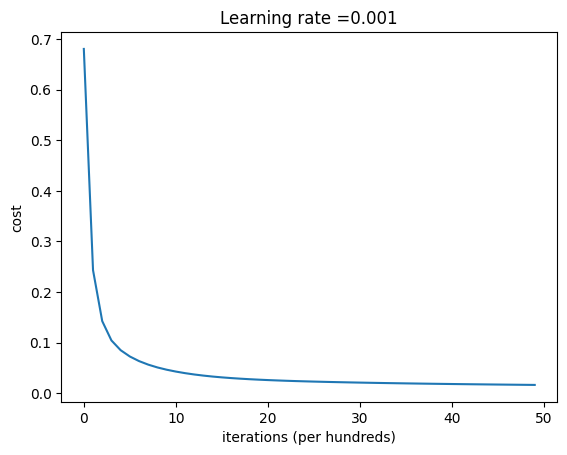

In [22]:
#5000 iterations

parameters, costs = two_layer_model(X_train.T, y_train.T, layers_dims = (n_x, n_h, n_y), num_iterations = 5000, print_cost=True)

plot_costs(costs, learning_rate)


In [23]:
#constants
layers_dims_l_layer = [16, 20, 7, 5, 1] #  4-layer model

In [24]:
def L_layer_model(X, Y, layers_dims, learning_rate = 0.01, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->LINEAR
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector, of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost
    
    # Parameters initialization.
    parameters = initialize_parameters_deep(layers_dims)
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation.
        AL, caches = L_model_forward(X, parameters)
        
        # Compute cost.
        cost = compute_cost(AL, Y)
    
        # Backward propagation.
        grads = L_model_backward(AL, Y, caches)
        
        # Update parameters.
        grads = clip_gradients(grads)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 1000 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

Cost after iteration 0: 0.5721707308531137
Cost after iteration 1000: 0.0456745647249072
Cost after iteration 2000: 0.025515530437227298
Cost after iteration 3000: 0.020385770163634347
Cost after iteration 4000: 0.01791728840751826
Cost after iteration 4999: 0.016436181203778877


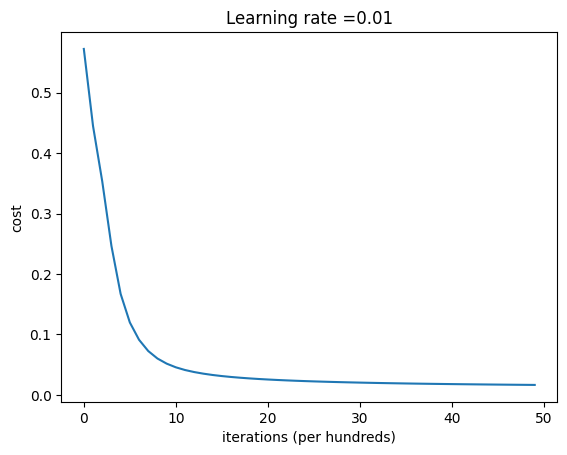

In [25]:
X_train_L_layer, X_test, y_train_L_Layer, y_test, (X_mean, X_std, y_mean, y_std) = load_split_dataset('data/compression_data_output.mat')

found_parameters, costs = L_layer_model(X_train_L_layer.T, y_train_L_Layer.T, layers_dims_l_layer, num_iterations = 5000, print_cost = True)

plot_costs(costs, learning_rate=0.01)

In [26]:
test_predictions, cache = L_model_forward(X_test.T, found_parameters)

In [27]:
train_predictions, cache = L_model_forward(X_train.T, found_parameters)

In [28]:
from scipy.io import savemat

data_to_save = {
    'X_test': X_test,
    'y_test': y_test,
    'test_predictions': test_predictions,
    'X_train': X_train,
    'y_train': y_train,
    'train_predictions': train_predictions

}

savemat('plots/decompression_data.mat', data_to_save)

In [29]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def forward_two_layer(X, parameters):
    """
    X: shape (n_x, m)
    parameters: dict with W1,b1,W2,b2
    Returns:
      AL: shape (n_y, m)
    """
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    # Layer 1: Z1 = W1X + b1, A1 = relu(Z1)
    Z1 = W1 @ X + b1
    A1 = np.maximum(0, Z1)

    # Layer 2: Z2 = W2A1 + b2
    Z2 = W2 @ A1 + b2

    # Output activation:
    # For regression, you typically want identity (no activation).
    AL = Z2
    return AL

def eval_regression(X, y, parameters, name="", y_mean=None, y_std=None):
    """
    X: shape (m, n_x) in your datasets
    y: shape (m, n_y)
    """
    # Convert to (n_x, m) and (n_y, m)
    X_in = X.T
    y_true = y.T

    y_pred = forward_two_layer(X_in, parameters)

    # Undo normalization if provided (choice == 2)
    if (y_mean is not None) and (y_std is not None):
        y_pred = y_pred * y_std + y_mean
        y_true = y_true * y_std + y_mean

    # Flatten for metrics (works great when n_y=1)
    yt = np.ravel(y_true)
    yp = np.ravel(y_pred)

    mse = mean_squared_error(yt, yp)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    print(f"\n{name} regression metrics:")
    print(f"  MSE : {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE : {mae:.6f}")
    print(f"  R^2 : {r2:.6f}")

    # quick peek
    print("  First 10 preds vs actual:")
    for i in range(min(10, len(yt))):
        print(f"    pred={yp[i]: .6f}   actual={yt[i]: .6f}")

    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

# ---- run evaluation ----
print("new version?")
if choice == 2:
    eval_regression(X_train, y_train, parameters, name="TRAIN", y_mean=y_mean, y_std=y_std)
    eval_regression(X_test,  y_test,  parameters, name="TEST",  y_mean=y_mean, y_std=y_std)
else:
    eval_regression(X_train, y_train, parameters, name="TRAIN")
    eval_regression(X_test,  y_test,  parameters, name="TEST")


new version?

TRAIN regression metrics:
  MSE : 5731242.207040
  RMSE: 2394.001296
  MAE : 1905.898841
  R^2 : 0.967376
  First 10 preds vs actual:
    pred=-562.713376   actual= 50.504386
    pred=-1166.425612   actual=-2414.138641
    pred=-3211.675628   actual=-4652.549342
    pred= 4480.784885   actual= 9737.209952
    pred= 10164.575390   actual= 12640.692982
    pred=-12195.075857   actual=-17099.868004
    pred=-11960.063289   actual=-12148.989035
    pred= 15528.856245   actual= 19753.524981
    pred=-2680.173542   actual=-3306.742325
    pred=-1224.194861   actual=-1097.957539

TEST regression metrics:
  MSE : 5542193.096045
  RMSE: 2354.186292
  MAE : 1866.607333
  R^2 : 0.967744
  First 10 preds vs actual:
    pred= 2738.595993   actual= 3360.485746
    pred=-5086.618921   actual=-5964.720449
    pred=-7090.573359   actual=-8554.391447
    pred= 5189.108086   actual= 5798.452926
    pred= 990.828125   actual= 1449.205044
    pred=-7412.671452   actual=-11619.538580
    pred=

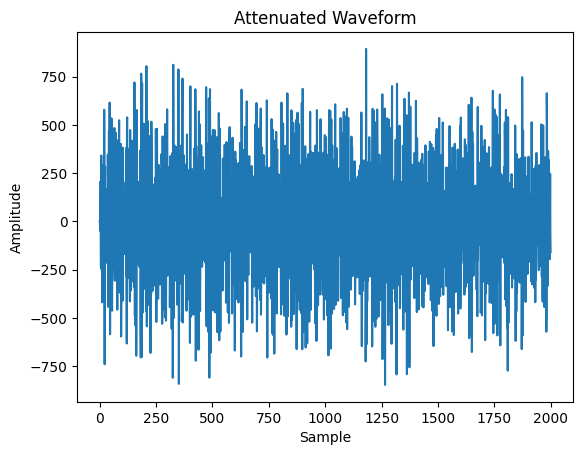

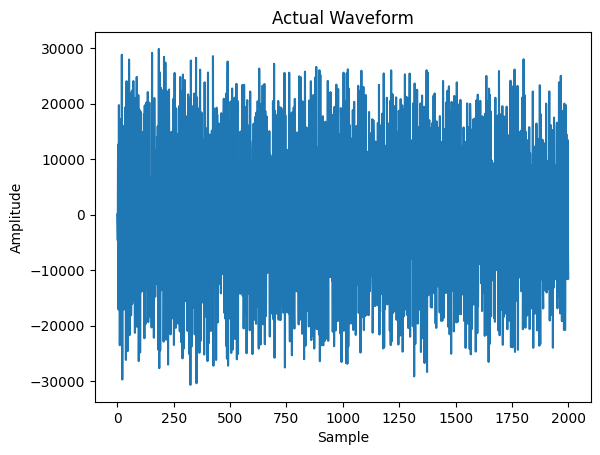

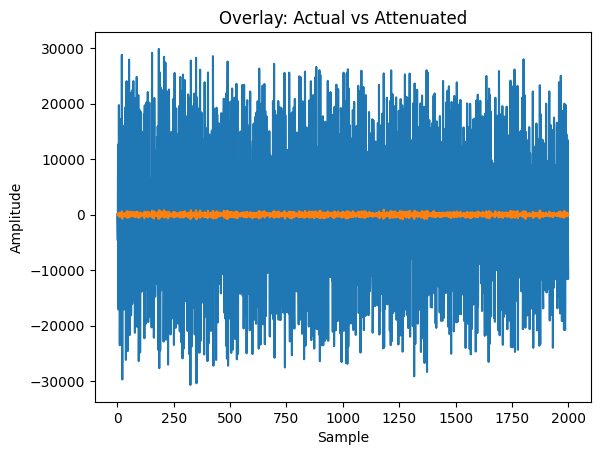

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat_path = "data/compression_data_output.mat"
signal_data = loadmat(mat_path)

attenuated = signal_data['train_input_real'].ravel()
actual = signal_data['train_output_real'].ravel()

N = 2000

plt.figure()
plt.plot(attenuated[:N])
plt.title("Attenuated Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(actual[:N])
plt.title("Actual Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(actual[:N])
plt.plot(attenuated[:N])
plt.title("Overlay: Actual vs Attenuated")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()


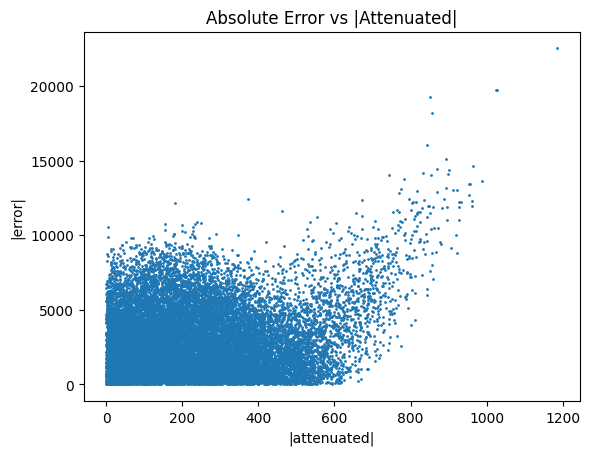

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x = attenuated, y = actual
x = attenuated.reshape(-1, 1)
y = actual

# Fit linear 
from sklearn.linear_model import LinearRegression
lin = LinearRegression().fit(x, y)
yhat = lin.predict(x)

res = y - yhat
abs_err = np.abs(res)
sq_err = res**2

plt.figure()
plt.scatter(np.abs(x.ravel()), abs_err, s=1)
plt.xlabel("|attenuated|")
plt.ylabel("|error|")
plt.title("Absolute Error vs |Attenuated|")
plt.show()



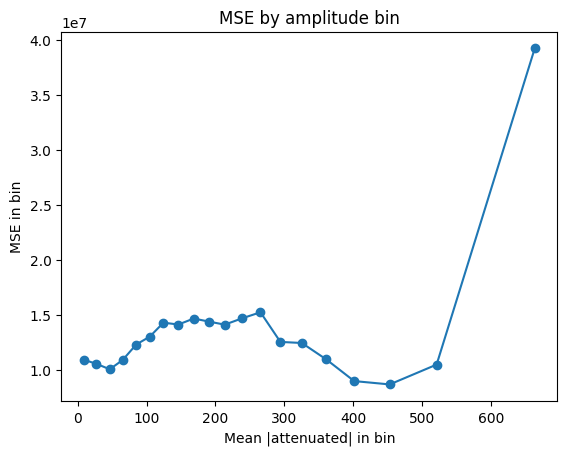

Top 1% |attenuated| contributes 7.0% of total SSE
Top 2% |attenuated| contributes 9.8% of total SSE
Top 5% |attenuated| contributes 14.4% of total SSE
Top 10% |attenuated| contributes 18.2% of total SSE


In [ ]:
ax = np.abs(x.ravel())
bins = np.quantile(ax, np.linspace(0, 1, 21)) 
bin_ids = np.digitize(ax, bins[1:-1], right=True)

mse_by_bin = []
count_by_bin = []
mid_by_bin = []

for b in range(20):
    idx = bin_ids == b
    mse_by_bin.append(np.mean(sq_err[idx]) if np.any(idx) else np.nan)
    count_by_bin.append(np.sum(idx))
    mid_by_bin.append(np.mean(ax[idx]) if np.any(idx) else np.nan)

plt.figure()
plt.plot(mid_by_bin, mse_by_bin, marker='o')
plt.xlabel("Mean |attenuated| in bin")
plt.ylabel("MSE in bin")
plt.title("MSE by amplitude bin")
plt.show()
order = np.argsort(ax)
sq_sorted = sq_err[order]
ax_sorted = ax[order]

total_sse = np.sum(sq_sorted)

def frac_sse(top_pct):
    k = int(len(sq_sorted) * (1 - top_pct/100))
    return np.sum(sq_sorted[k:]) / total_sse

for p in [1, 2, 5, 10]:
    print(f"Top {p}% |attenuated| contributes {frac_sse(p)*100:.1f}% of total SSE")


In [38]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_two_line_models(x_tr, y_tr, t):
    ax_tr = np.abs(x_tr.ravel())
    low = ax_tr < t
    high = ~low

    m1 = LinearRegression().fit(x_tr[low], y_tr[low])
    m2 = LinearRegression().fit(x_tr[high], y_tr[high])
    return m1, m2

def predict_soft_piecewise(x, m1, m2, t, s):
    ax = np.abs(x.ravel())
    g = sigmoid((ax - t) / s)  # shape (n,)
    y1 = m1.predict(x)
    y2 = m2.predict(x)
    return (1 - g) * y1 + g * y2

# --- data ---
x = attenuated.reshape(-1, 1)
y = actual

# same split style you used
N = len(x)
split = N // 2
x_tr, x_te = x[:split], x[split:]
y_tr, y_te = y[:split], y[split:]

ax_te = np.abs(x_te.ravel())

# candidate thresholds: focus on where saturation likely begins
t_candidates = np.quantile(ax_te, np.linspace(0.6, 0.95, 25))

# candidate smoothness values (in units of |x| amplitude)
s_candidates = [5, 10, 20, 40, 80]

best = None
for t in t_candidates:
    m1, m2 = fit_two_line_models(x_tr, y_tr, t)
    for s in s_candidates:
        yhat = predict_soft_piecewise(x_te, m1, m2, t, s)
        mse = mean_squared_error(y_te, yhat)
        r2 = r2_score(y_te, yhat)
        if best is None or mse < best["mse"]:
            best = {"mse": mse, "r2": r2, "t": float(t), "s": float(s),
                    "m1": m1, "m2": m2}

print("Best soft-piecewise:")
print("  t (threshold) =", best["t"])
print("  s (smoothness)=", best["s"])
print("  TEST MSE      =", best["mse"])
print("  TEST R^2      =", best["r2"])

print("\nLow regime:  y = %.6f x + %.6f" % (best["m1"].coef_[0], best["m1"].intercept_))
print("High regime: y = %.6f x + %.6f" % (best["m2"].coef_[0], best["m2"].intercept_))


Best soft-piecewise:
  t (threshold) = 421.20783874338446
  s (smoothness)= 40.0
  TEST MSE      = 10726647.080913942
  TEST R^2      = 0.937570905369485

Low regime:  y = 49.202336 x + -17.761485
High regime: y = 38.532254 x + 106.419571


In [39]:
def make_weights_from_y(y_true_unscaled, q=0.9, alpha=9.0, eps=1e-12):
    """
    y_true_unscaled: shape (m,) or (m,1)
    q: quantile threshold for "large" values
    alpha: how much more weight to give large values (alpha=9 means 10x vs baseline)
    """
    yt = np.ravel(y_true_unscaled)
    t = np.quantile(np.abs(yt), q)
    w = 1.0 + alpha * (np.abs(yt) >= t).astype(float)
    return w

def weighted_mse(y_true, y_pred, w, eps=1e-12):
    yt = np.ravel(y_true)
    yp = np.ravel(y_pred)
    w  = np.ravel(w)
    return np.sum(w * (yt - yp)**2) / (np.sum(w) + eps)

def weighted_rmse(y_true, y_pred, w, eps=1e-12):
    return np.sqrt(weighted_mse(y_true, y_pred, w, eps))

from sklearn.linear_model import LinearRegression

def fit_linear_on_windows(X_train_scaled, y_train_scaled):
    lin = LinearRegression().fit(X_train_scaled, y_train_scaled)
    return lin

def predict_linear_unscaled(lin, X_scaled, y_mean, y_std):
    yhat_scaled = lin.predict(X_scaled)
    return yhat_scaled * y_std + y_mean
def predict_nn_unscaled(parameters, X_scaled, y_mean, y_std):
    yhat_scaled = forward_two_layer(X_scaled.T, parameters).T  # back to (m,1)
    return yhat_scaled * y_std + y_mean


In [40]:
# Fit linear baseline on the same scaled windows
lin = fit_linear_on_windows(X_train, y_train)

# Unscale ground truth
y_test_un = y_test * y_std + y_mean

# Predictions (unscaled)
yhat_lin = predict_linear_unscaled(lin, X_test, y_mean, y_std)
yhat_nn  = predict_nn_unscaled(parameters, X_test, y_mean, y_std)

# Weights computed from true y (unscaled) on TEST
w_test = make_weights_from_y(y_test_un, q=0.9, alpha=9.0)

print("UNWEIGHTED MSE:")
print("  linear:", np.mean((y_test_un - yhat_lin)**2))
print("  nn    :", np.mean((y_test_un - yhat_nn)**2))

print("\nWEIGHTED MSE (q=0.9, alpha=9 -> top 10% gets 10x weight):")
print("  linear:", weighted_mse(y_test_un, yhat_lin, w_test))
print("  nn    :", weighted_mse(y_test_un, yhat_nn,  w_test))


UNWEIGHTED MSE:
  linear: 6705684.902391539
  nn    : 339539338.4646936

WEIGHTED MSE (q=0.9, alpha=9 -> top 10% gets 10x weight):
  linear: 11312540.05104723
  nn    : 6786234.873389484


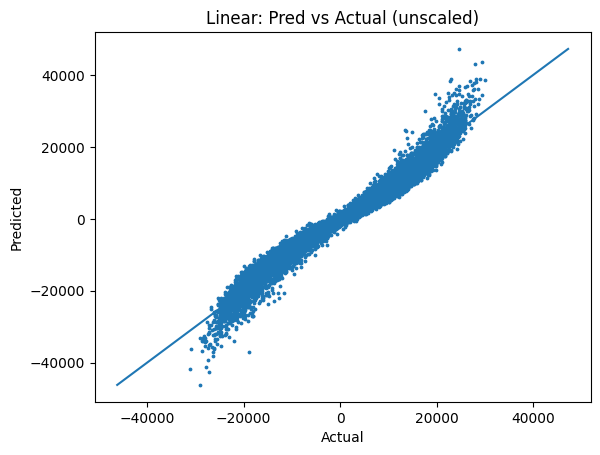

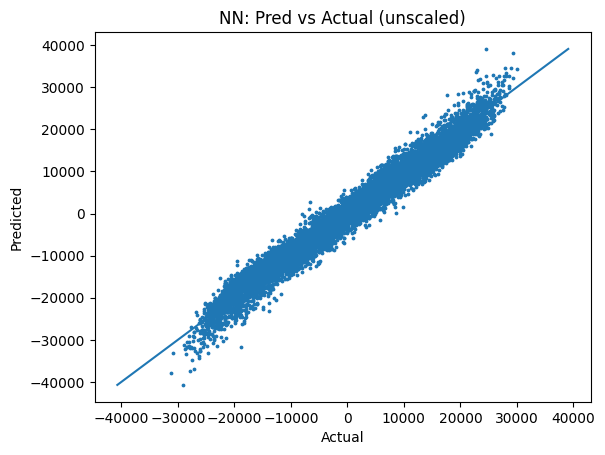

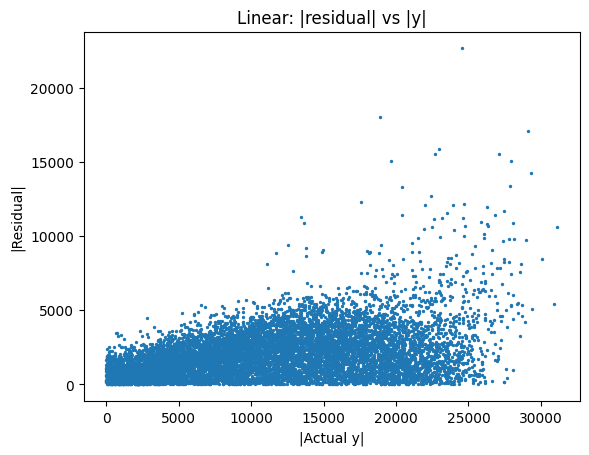

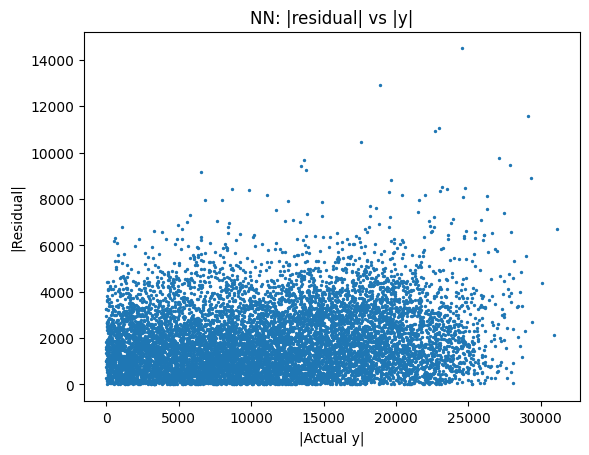

In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_actual(y_true, y_pred, title=""):
    yt = np.ravel(y_true); yp = np.ravel(y_pred)
    plt.figure()
    plt.scatter(yt, yp, s=3)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

def plot_abs_residual_vs_abs_y(y_true, y_pred, title=""):
    yt = np.ravel(y_true); yp = np.ravel(y_pred)
    err = np.abs(yt - yp)
    plt.figure()
    plt.scatter(np.abs(yt), err, s=2)
    plt.xlabel("|Actual y|")
    plt.ylabel("|Residual|")
    plt.title(title)
    plt.show()

plot_pred_vs_actual(y_test_un, yhat_lin, "Linear: Pred vs Actual (unscaled)")
plot_pred_vs_actual(y_test_un, yhat_nn,  "NN: Pred vs Actual (unscaled)")

plot_abs_residual_vs_abs_y(y_test_un, yhat_lin, "Linear: |residual| vs |y|")
plot_abs_residual_vs_abs_y(y_test_un, yhat_nn,  "NN: |residual| vs |y|")


Subset size: 153 out of 10016
Linear on subset |y| < 300.0:
  MSE: 1050187.796746949
  MAE: 836.846000660008


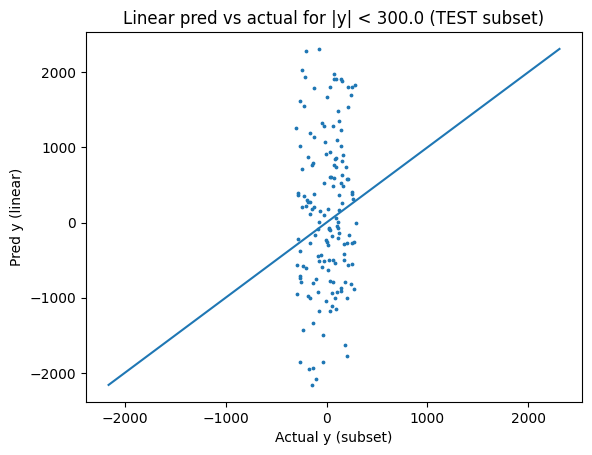

In [42]:
thr = 300.0

# Unscale ground truth and linear predictions (TEST)
y_test_un = y_test * y_std + y_mean
yhat_lin  = lin.predict(X_test) * y_std + y_mean  # lin already fit on scaled windows

yt = np.ravel(y_test_un)
yp = np.ravel(yhat_lin)

mask = np.abs(yt) < thr

print("Subset size:", np.sum(mask), "out of", len(mask))

mse_sub = np.mean((yt[mask] - yp[mask])**2)
mae_sub = np.mean(np.abs(yt[mask] - yp[mask]))

print(f"Linear on subset |y| < {thr}:")
print("  MSE:", mse_sub)
print("  MAE:", mae_sub)

# Scatter: actual vs pred for subset
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(yt[mask], yp[mask], s=3)
lo = min(yt[mask].min(), yp[mask].min())
hi = max(yt[mask].max(), yp[mask].max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Actual y (subset)")
plt.ylabel("Pred y (linear)")
plt.title(f"Linear pred vs actual for |y| < {thr} (TEST subset)")
plt.show()


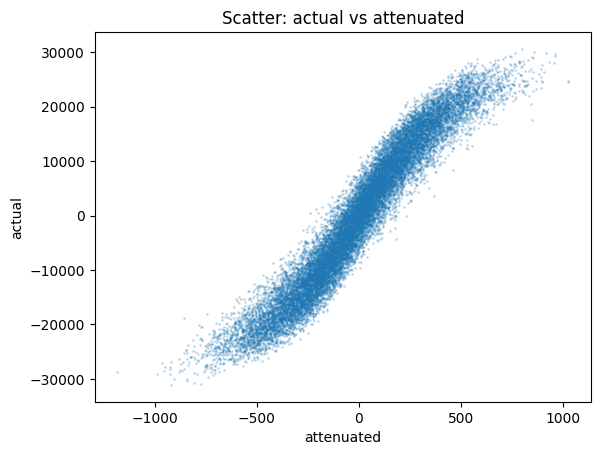

In [43]:
M = 200000  # or smaller if slow
x = attenuated[:M]
y = actual[:M]

plt.figure()
plt.scatter(x, y, s=1, alpha=0.2)
plt.xlabel("attenuated")
plt.ylabel("actual")
plt.title("Scatter: actual vs attenuated")
plt.show()


In [44]:
print("Keys in mat:", signal_data.keys())
print("train_input_real shape:", signal_data["train_input_real"].shape)
print("train_output_real shape:", signal_data["train_output_real"].shape)

print("First 10 attenuated:", attenuated[:10])
print("First 10 actual    :", actual[:10])


Keys in mat: dict_keys(['__header__', '__version__', '__globals__', 'train_input_real', 'train_output_real'])
train_input_real shape: (20032, 1)
train_output_real shape: (20032, 1)
First 10 attenuated: [   0.708441     -9.31860076  -48.88473716   71.76471888  208.34089876
 -225.0170698  -245.44085511  341.24842415  -53.35372811  -44.45949685]
First 10 actual    : [    50.50438596  -2414.13864121  -4652.54934211   9737.20995231
  12640.69298246 -17099.86800356 -12148.98903509  19753.52498145
  -3306.74232456  -1097.95753858]


In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

X = X_train  # distorted windows/signals (shape: N x d)
y = y_train_un  # pre-distortion target scalar (or use the right target)

X = np.asarray(X)
y = np.ravel(y)

nn = NearestNeighbors(n_neighbors=2, algorithm="auto").fit(X)
dist, idx = nn.kneighbors(X)  # dist[:,0]=0 self, dist[:,1]=nearest other

nearest_dist = dist[:,1]
nearest_j = idx[:,1]
dy = np.abs(y - y[nearest_j])

# "collision" candidates: nearly identical distorted inputs but different outputs
eps = np.percentile(nearest_dist, 1)     # smallest 1% distances
big = np.percentile(dy, 99)             # biggest 1% output gaps
bad = np.where((nearest_dist <= eps) & (dy >= big))[0]

print("eps input-dist:", eps)
print("big output-gap:", big)
print("num bad collisions:", len(bad))

# show a few examples
for i in bad[:10]:
    j = nearest_j[i]
    print(f"i={i}, j={j}, ||dx||={nearest_dist[i]:.4g}, |dy|={dy[i]:.4g}, y_i={y[i]:.4g}, y_j={y[j]:.4g}")